In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# Fix numpy conflict first, then install captum
import subprocess
subprocess.run(['pip', 'install', '-q', 'captum'], capture_output=True)

# Verify numpy is working
import numpy as np
print(f"✅ Numpy version: {np.__version__}")

import pandas as pd
print(f"✅ Pandas version: {pd.__version__}")

import torch
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

✅ Numpy version: 1.26.4
✅ Pandas version: 2.3.3
✅ PyTorch version: 2.9.0+cu126
✅ GPU: Tesla P100-PCIE-16GB


In [5]:
import os, glob, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {DEVICE}")

# Paths
FOLDER     = "/kaggle/input/datasets/saifzaman123445/daicwoz/daicwoz/daicwoz/"
TRAIN_CSV  = FOLDER + "train_split_Depression_AVEC2017.csv"
DEV_CSV    = FOLDER + "dev_split_Depression_AVEC2017.csv"
MAX_FRAMES = 512   # truncate/pad all sequences to this length
BATCH_SIZE = 16
EPOCHS     = 30
LR         = 1e-4

Using: cuda


In [4]:
import os

# Find the exact location of your CSV files
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.csv') and ('train' in f.lower() or 'dev' in f.lower() or 'test' in f.lower()):
            print(os.path.join(root, f))

/kaggle/input/datasets/saifzaman123445/daicwoz/daicwoz/daicwoz/test_split_Depression_AVEC2017.csv
/kaggle/input/datasets/saifzaman123445/daicwoz/daicwoz/daicwoz/dev_split_Depression_AVEC2017.csv
/kaggle/input/datasets/saifzaman123445/daicwoz/daicwoz/daicwoz/full_test_split.csv
/kaggle/input/datasets/saifzaman123445/daicwoz/daicwoz/daicwoz/train_split_Depression_AVEC2017.csv


**Feature Extraction (Keeping Time Series)**

In [6]:
def load_participant_features(participant_id, max_frames=MAX_FRAMES):
    """
    Load COVAREP + FORMANT for one participant.
    Returns tensor of shape [max_frames, 79]
    """
    cov_path  = os.path.join(FOLDER, f"{participant_id}_COVAREP.csv")
    form_path = os.path.join(FOLDER, f"{participant_id}_FORMANT.csv")
    
    if not (os.path.exists(cov_path) and os.path.exists(form_path)):
        return None
    
    cov_df  = pd.read_csv(cov_path).replace([np.inf, -np.inf], np.nan).fillna(0)
    form_df = pd.read_csv(form_path).replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # Align frame counts (take minimum)
    min_frames = min(len(cov_df), len(form_df))
    cov_df  = cov_df.iloc[:min_frames]
    form_df = form_df.iloc[:min_frames]
    
    # Concatenate features: [frames, 74+5=79]
    features = np.concatenate([cov_df.values, form_df.values], axis=1)
    
    # Truncate or pad to max_frames
    if len(features) >= max_frames:
        features = features[:max_frames]
    else:
        pad = np.zeros((max_frames - len(features), features.shape[1]))
        features = np.concatenate([features, pad], axis=0)
    
    return features.astype(np.float32)  # [max_frames, 79]


# Build dataset from CSV
def build_dataset(csv_path):
    labels_df = pd.read_csv(csv_path)
    X, y, ids = [], [], []
    
    for _, row in labels_df.iterrows():
        pid   = int(row['Participant_ID'])
        label = int(row['PHQ8_Binary'])
        feats = load_participant_features(pid)
        
        if feats is not None:
            X.append(feats)
            y.append(label)
            ids.append(pid)
    
    print(f"Loaded {len(X)} participants | Depressed: {sum(y)} | Not: {len(y)-sum(y)}")
    return np.array(X), np.array(y), ids


print("Loading training data...")
X_train, y_train, train_ids = build_dataset(TRAIN_CSV)
print("\nLoading validation data...")
X_val, y_val, val_ids = build_dataset(DEV_CSV)

print(f"\nX_train shape: {X_train.shape}")  # [N, 512, 79]
print(f"X_val shape  : {X_val.shape}")

Loading training data...
Loaded 107 participants | Depressed: 30 | Not: 77

Loading validation data...
Loaded 34 participants | Depressed: 12 | Not: 22

X_train shape: (107, 512, 79)
X_val shape  : (34, 512, 79)


**Normalize Features**

In [7]:
# Normalize across all participants (fit on train only)
N_train, T, F = X_train.shape

# Reshape to [N*T, F] for scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.reshape(-1, F)).reshape(N_train, T, F)
X_val_scaled   = scaler.transform(X_val.reshape(-1, F)).reshape(X_val.shape[0], T, F)

print("✅ Normalization done")
print(f"Train: {X_train_scaled.shape} | Val: {X_val_scaled.shape}")

✅ Normalization done
Train: (107, 512, 79) | Val: (34, 512, 79)


**PyTorch Dataset**

In [8]:
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = AudioDataset(X_train_scaled, y_train)
val_dataset   = AudioDataset(X_val_scaled, y_val)

# Class weights for imbalanced data (replaces SMOTE for deep learning)
class_counts  = np.bincount(y_train)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]], 
    dtype=torch.float32
).to(DEVICE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Class weights: {class_weights}")

Train batches: 7 | Val batches: 3
Class weights: tensor([0.0130, 0.0333], device='cuda:0')


**Transformer Model with Attention**

In [11]:
# Transformer model with attention

class AudioTransformer(nn.Module):
    def __init__(self, input_dim=79, d_model=128, nhead=4, 
                 num_layers=2, num_classes=2, dropout=0.3):
        super().__init__()
        
        # Project input features to d_model
        self.input_proj = nn.Linear(input_dim, d_model)
        self.dropout    = nn.Dropout(dropout)
        
        # Positional encoding (learnable)
        self.pos_enc = nn.Parameter(torch.randn(1, MAX_FRAMES, d_model) * 0.01)
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=256, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Attention pooling over time (this gives us interpretable weights!)
        self.attn_pool = nn.Linear(d_model, 1)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x, return_attention=False):
        # x: [B, T, input_dim]
        x = self.input_proj(x)          # [B, T, d_model]
        x = x + self.pos_enc            # add positional encoding
        x = self.dropout(x)
        
        x = self.transformer(x)         # [B, T, d_model]
        
        # Attention pooling
        attn_weights = torch.softmax(
            self.attn_pool(x), dim=1
        )                               # [B, T, 1]
        
        x_pooled = (x * attn_weights).sum(dim=1)  # [B, d_model]
        
        logits = self.classifier(x_pooled)         # [B, 2]
        
        if return_attention:
            return logits, attn_weights.squeeze(-1)  # also return [B, T]
        return logits


# Reinitialize model with stronger regularization
model = AudioTransformer(
    input_dim=79,
    d_model=128,
    nhead=4,
    num_layers=2,
    num_classes=2,
    dropout=0.4       # increased from 0.3
).to(DEVICE)

print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 349,251


**Training Loop**

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

SAVE_PATH = '/kaggle/working/audio_transformer_best.pt'

# Early stopping settings
best_f1         = 0
patience        = 10      # stop if no improvement for 10 epochs
patience_counter = 0
best_epoch      = 0

train_losses, val_losses, f1_scores = [], [], []

for epoch in range(50):  # increase max epochs, early stopping will cut it
    # ── Train ──
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ──
    model.eval()
    val_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits    = model(X_batch)
            loss      = criterion(logits, y_batch)
            val_loss += loss.item()
            preds     = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    f1        = f1_score(all_labels, all_preds, average='macro')

    train_losses.append(avg_train)
    val_losses.append(avg_val)
    f1_scores.append(f1)

    scheduler.step(avg_val)

    # ── Early Stopping ──
    if f1 > best_f1:
        best_f1          = f1
        best_epoch       = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss: {avg_train:.4f} | "
              f"Val Loss: {avg_val:.4f} | "
              f"F1: {f1:.4f} | "
              f"Best F1: {best_f1:.4f} | "
              f"Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        print(f"Best F1: {best_f1:.4f} at epoch {best_epoch}")
        break

print(f"\n✅ Training complete. Best F1: {best_f1:.4f} at epoch {best_epoch}")

Epoch 05 | Train Loss: 0.6688 | Val Loss: 0.6568 | F1: 0.6780 | Best F1: 0.7589 | Patience: 3/10
Epoch 10 | Train Loss: 0.6334 | Val Loss: 0.6442 | F1: 0.6886 | Best F1: 0.7589 | Patience: 8/10

⏹️ Early stopping at epoch 12
Best F1: 0.7589 at epoch 2

✅ Training complete. Best F1: 0.7589 at epoch 2


**Evaluation**

In [14]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(DEVICE)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1)[:, 1]
        preds   = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.cpu().numpy())

print("=== Audio Modality Results ===")
print(classification_report(all_labels, all_preds, 
      target_names=['Not Depressed', 'Depressed']))
print(f"AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}")

=== Audio Modality Results ===
               precision    recall  f1-score   support

Not Depressed       0.80      0.91      0.85        22
    Depressed       0.78      0.58      0.67        12

     accuracy                           0.79        34
    macro avg       0.79      0.75      0.76        34
 weighted avg       0.79      0.79      0.79        34

AUC-ROC: 0.7917


**Integrated Gradients (Explainability)**

In [15]:
from captum.attr import IntegratedGradients

# Load best model
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

# Wrapper needed for Captum (takes only input tensor)
def model_forward(x):
    return model(x)

ig = IntegratedGradients(model_forward)

# Take one depressed participant from validation set
sample_idx = next(i for i, l in enumerate(y_val) if l == 1)
sample_input = torch.tensor(
    X_val_scaled[sample_idx:sample_idx+1], 
    dtype=torch.float32
).to(DEVICE)

baseline = torch.zeros_like(sample_input).to(DEVICE)

# Compute attributions for "depressed" class (index 1)
attributions, delta = ig.attribute(
    sample_input,
    baselines=baseline,
    target=1,
    return_convergence_delta=True
)

# Sum attributions over feature dimension → per-frame importance
frame_importance = attributions.squeeze(0).sum(dim=-1).cpu().detach().numpy()
# shape: [512] — one value per time frame

print(f"Convergence delta: {delta.item():.6f}")  # should be close to 0
print(f"Frame importance shape: {frame_importance.shape}")
print(f"Top 10 most important frames: {np.argsort(np.abs(frame_importance))[-10:]}")

Convergence delta: 0.001008
Frame importance shape: (512,)
Top 10 most important frames: [464  85   1 383 125 384 385   0  84   4]


 **Visualize Attention & IG**

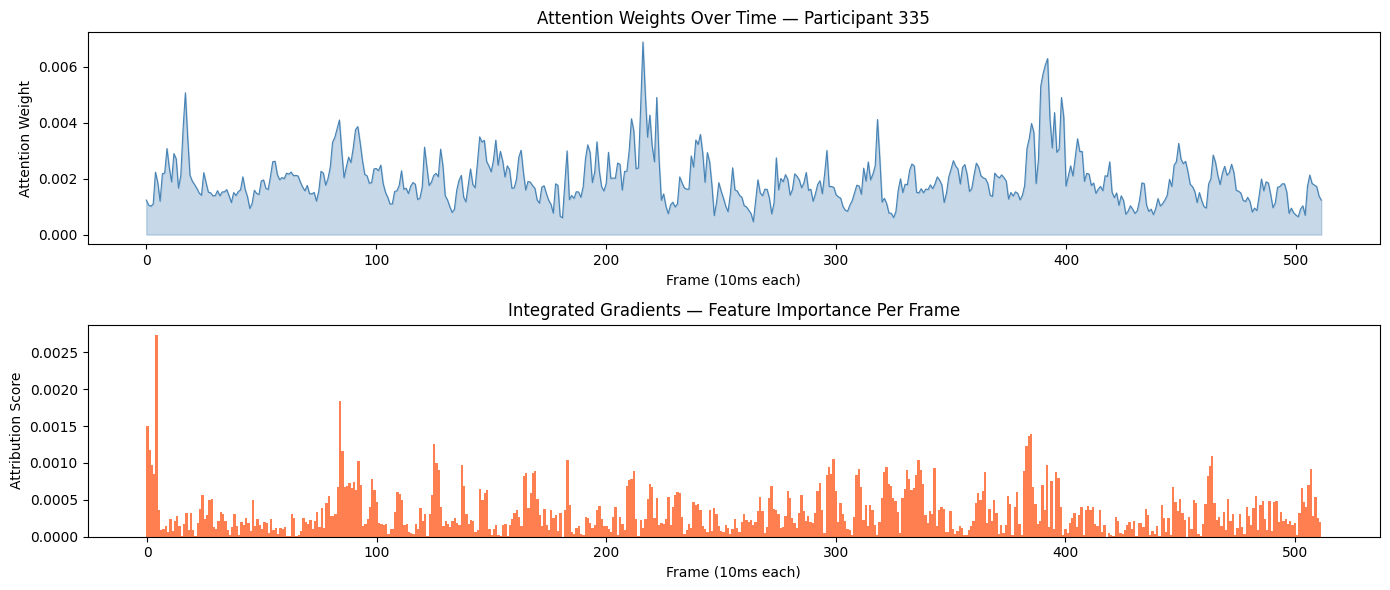

✅ Plot saved


In [16]:
import matplotlib.pyplot as plt

# Get attention weights for same sample
with torch.no_grad():
    _, attn_weights = model(sample_input, return_attention=True)

attn = attn_weights.squeeze(0).cpu().numpy()  # [512]

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Attention weights
axes[0].plot(attn, color='steelblue', linewidth=0.8)
axes[0].fill_between(range(len(attn)), attn, alpha=0.3, color='steelblue')
axes[0].set_title(f'Attention Weights Over Time — Participant {val_ids[sample_idx]}')
axes[0].set_xlabel('Frame (10ms each)')
axes[0].set_ylabel('Attention Weight')

# Integrated Gradients
ig_abs = np.abs(frame_importance)
axes[1].bar(range(len(ig_abs)), ig_abs, color='coral', width=1.0)
axes[1].set_title('Integrated Gradients — Feature Importance Per Frame')
axes[1].set_xlabel('Frame (10ms each)')
axes[1].set_ylabel('Attribution Score')

plt.tight_layout()
plt.savefig('/kaggle/working/audio_explainability.png', dpi=150)
plt.show()
print("✅ Plot saved")